In [77]:
import warnings
warnings.filterwarnings("ignore")

## Imports

In [78]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [79]:
from funcoes_psi import *
from funcoes_escoragem import *

## Diretório

In [80]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Base

In [81]:
df_raw = pd.read_csv(ANALYTICS_DIR/"df_raw_blend4_dev.csv").drop(columns=["Unnamed: 0"])
df_raw["safra"] = df_raw["requested_at"].astype(str).str[:7]
df_raw = df_raw[df_raw["safra"] <= "2025-08"]
df_raw

,contract_id,requested_at,request_month,pred_blend4_1_to_score,predict_blend3_2_to_score,FLAG_TESTE,FLAG_OOT,FLAG_OOT_TARGET_MATURADO,FLAG_COMPARA_MESMA_PROPORCAO_STATUS,status_v2,...,age,property_type,qtde_restricoes__consulta_realizada,rental_value,income,agency_pc4_mais_100_contratos__pc_categorias,city_pc4_mais_100_contratos__pc_categorias,flag_tem__contratos_anteriores,flag_teve_boleto_atrasado__contratos_anteriores,safra
0,1913006,2024-09-01,2024-09-01,503.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,30.0,1.0,NaN,2310.0,4384.0,NaN,NaN,NaN,NaN,2024-09
1,1913007,2024-09-01,2024-09-01,230.0,NaN,1.0,0.0,0.0,NaN,nao_aprovado,...,20.0,1.0,NaN,1942.5,1575.5,NaN,NaN,NaN,NaN,2024-09
2,1913011,2024-09-01,2024-09-01,749.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,0.0,1995.0,42196.0,NaN,0.073830,0.0,0.0,2024-09
3,1913017,2024-09-01,2024-09-01,422.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,2.0,1995.0,6507.5,NaN,0.096200,0.0,0.0,2024-09
4,1913018,2024-09-01,2024-09-01,194.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,27.0,1.0,2.0,2730.0,2123.5,NaN,0.138889,0.0,0.0,2024-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356567,3076092,2025-08-31,2025-08-01,260.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,22.0,1.0,6.0,787.5,8836.5,NaN,NaN,0.0,0.0,2025-08
1356568,3076098,2025-08-31,2025-08-01,346.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,42.0,1.0,1.0,945.0,1233.0,NaN,NaN,0.0,0.0,2025-08
1356569,3076101,2025-08-31,2025-08-01,207.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,24.0,1.0,1.0,651.0,1507.0,NaN,NaN,0.0,0.0,2025-08
1356570,3076108,2025-08-31,2025-08-01,392.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,21.0,1.0,0.0,1627.5,5206.0,NaN,0.110814,0.0,0.0,2025-08


In [82]:
df_raw[["rental_value"]].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9])

,rental_value
count,1.070236e+06
mean,1.897829e+03
std,1.429879e+03
min,1.050000e+00
1%,5.775000e+02
5%,7.350000e+02
10%,8.400000e+02
25%,1.081500e+03
50%,1.532622e+03
75%,2.164575e+03


In [83]:
df_raw[df_raw["rental_value"] <= 100]

,contract_id,requested_at,request_month,pred_blend4_1_to_score,predict_blend3_2_to_score,FLAG_TESTE,FLAG_OOT,FLAG_OOT_TARGET_MATURADO,FLAG_COMPARA_MESMA_PROPORCAO_STATUS,status_v2,...,age,property_type,qtde_restricoes__consulta_realizada,rental_value,income,agency_pc4_mais_100_contratos__pc_categorias,city_pc4_mais_100_contratos__pc_categorias,flag_tem__contratos_anteriores,flag_teve_boleto_atrasado__contratos_anteriores,safra
195929,2767991,2025-06-25,2025-06-01,784.0,770.0,NaN,1.0,1.0,1.0,elegivel_n_ativado,...,34.0,1.0,0.0,2.2260,7877.5,NaN,0.090535,0.0,0.0,2025-06
195930,2767997,2025-06-25,2025-06-01,451.0,546.0,NaN,1.0,1.0,1.0,nao_aprovado,...,20.0,1.0,0.0,1.7745,1438.5,NaN,0.090535,0.0,0.0,2025-06
206622,2812305,2025-07-04,2025-07-01,674.0,NaN,NaN,1.0,1.0,NaN,elegivel_n_ativado,...,57.0,1.0,0.0,1.5960,5343.0,NaN,NaN,1.0,0.0,2025-07
206623,2812308,2025-07-04,2025-07-01,864.0,NaN,NaN,1.0,1.0,NaN,elegivel_n_ativado,...,32.0,1.0,0.0,2.1000,2945.5,NaN,NaN,0.0,0.0,2025-07
206624,2812309,2025-07-04,2025-07-01,633.0,568.0,NaN,1.0,1.0,1.0,elegivel_n_ativado,...,27.0,1.0,0.0,1.4910,3904.5,NaN,NaN,0.0,0.0,2025-07
206625,2812310,2025-07-04,2025-07-01,498.0,500.0,NaN,1.0,1.0,1.0,elegivel_n_ativado,...,34.0,1.0,2.0,1.2705,2945.5,NaN,NaN,0.0,0.0,2025-07
206626,2812312,2025-07-04,2025-07-01,639.0,642.0,NaN,1.0,1.0,1.0,elegivel_n_ativado,...,29.0,1.0,0.0,1.2600,4178.5,NaN,NaN,0.0,0.0,2025-07
213881,2842170,2025-07-11,2025-07-01,806.0,724.0,NaN,1.0,1.0,1.0,elegivel_n_ativado,...,36.0,1.0,0.0,3.9375,15207.0,NaN,0.105714,1.0,0.0,2025-07
227569,2908026,2025-07-24,2025-07-01,384.0,293.0,NaN,1.0,1.0,1.0,nao_aprovado,...,26.0,1.0,6.0,3.1500,2329.0,0.202929,0.096587,1.0,1.0,2025-07
250097,3001901,2025-08-14,2025-08-01,296.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,53.0,1.0,2.0,1.6800,9179.0,NaN,0.110814,0.0,0.0,2025-08


In [106]:
df_prod = pd.read_csv(ANALYTICS_DIR/"df_predict_blend4.csv")
# df_prod = df_prod[df_prod["message_decisao"] == "BLEND_4"].copy()
df_prod["safra"] = df_prod["requested_at"].astype(str).str[:7]
# df_prod = df_prod[df_prod["safra"] == "2026-07"]
df_prod

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,qtd_proponentes,score_imobiliaria,model,id_consulta,id_funcionalidade,documento,...,qtde_restricoes__consulta_realizada__normalized4_1,income_commitment__normalized4_1,agency_pc4_mais_100_contratos__pc_categorias__normalized4_1,city_pc4_mais_100_contratos__pc_categorias__normalized4_1,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4,rating_cl_pol_blend4,safra
0,64043274068,4350090,2026-07-08,2026-07-13,1,E,BLEND3_3,6089467,15,64043274068,...,4.0,0.000000,0.000000,-0.103572,0.535834,464.0,B,NaN,8.C,2026-07
1,11946036293,4355232,2026-07-10,2026-07-10,1,F,BLEND3_3,6075024,15,11946036293,...,0.0,0.000000,0.000000,0.000000,0.492096,508.0,A,NaN,7.B,2026-07
2,12369868902,4384487,2026-07-16,2026-07-16,1,NI,BLEND3_3,6110919,15,12369868902,...,0.0,0.000000,0.000000,0.144846,0.523590,476.0,B,NaN,8.C,2026-07
3,15619051781,4083746,2026-05-01,2026-05-01,1,NI,BVS_CUSTOM,5737594,28,15619051781,...,0.0,0.000000,0.000000,1.471828,0.562370,438.0,C,NaN,9.D+,2026-05
4,85020680087,4213332,2026-06-03,2026-06-03,1,B,BLEND3_3,5898713,35,85020680087,...,0.0,0.444747,-0.020166,0.106385,0.571670,428.0,C,B,9.D+,2026-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327912,2776113854,4050315,2026-04-27,2026-04-27,1,D,BLEND3_3,5714540,37,2776113854,...,1.0,0.000000,0.000000,-1.819305,0.461464,539.0,A,A,6.B,2026-04
327913,20647506653,4276305,2026-06-19,2026-06-19,1,A,BLEND3_3,5976859,37,20647506653,...,0.0,-0.312875,0.000000,-1.026901,0.466172,534.0,A,A,6.B,2026-06
327914,70837430887,4276621,2026-06-19,2026-06-19,1,NI,BLEND3_3,5977279,37,70837430887,...,2.0,0.584314,0.000000,0.320622,0.549197,451.0,B,E,8.C,2026-06
327915,40682918881,4284717,2026-06-23,2026-06-23,1,E,BLEND3_3,5987305,37,40682918881,...,5.0,0.004071,-0.018492,0.174016,0.588491,412.0,C,C,9.D+,2026-06


In [107]:
df_prod[["rental_value"]].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9])

,rental_value
count,2.852480e+05
mean,8.589483e+08
std,4.587410e+11
min,1.000000e+00
1%,6.000000e+02
5%,7.800000e+02
10%,9.000000e+02
25%,1.200000e+03
50%,1.600000e+03
75%,2.300000e+03


In [108]:
df_prod[df_prod["rental_value"] < 100][["contract_id", "requested_at","rental_value"]]

,contract_id,requested_at,rental_value
3275,4261600,2026-06-16,1.18
4161,4261597,2026-06-16,1.76
6202,4309924,2026-06-29,1.65
20836,4261604,2026-06-16,1.65
22411,4261594,2026-06-16,1.14
29966,4309914,2026-06-29,1.35
60557,4261607,2026-06-16,1.02
71849,4309917,2026-06-29,2.40
74762,4261601,2026-06-16,1.00
80359,4309922,2026-06-29,1.40


In [109]:
df_prod[df_prod["rental_value"] > 1e+08][["contract_id", "requested_at","rental_value"]]

,contract_id,requested_at,rental_value
15953,4280408,2026-06-22,2.450072e+14
82595,4310049,2026-06-29,4.343594e+09
285265,4356728,2026-07-10,9.779630e+08


## Gráfico de Acompanhamento

In [87]:
df_raw.groupby("safra", as_index=False)["rental_value"].agg(
    n="count",
    mean="mean",
    p25=lambda s: s.quantile(0.25),
    p50=lambda s: s.quantile(0.50),
    p75=lambda s: s.quantile(0.75),
)

,safra,n,mean,p25,p50,p75
0,2024-09,39121,1839.370431,1050.0000,1470.0,2100.0
1,2024-10,44731,1827.219128,1050.0000,1470.0,2100.0
2,2024-11,40001,1826.157945,1050.0000,1470.0,2100.0
3,2024-12,43060,1858.356420,1050.0000,1470.0,2100.0
4,2025-01,109011,1869.225103,1050.0000,1512.0,2100.0
5,2025-02,108527,1930.252747,1102.5000,1575.0,2205.0
6,2025-03,96018,1918.120248,1102.5000,1575.0,2205.0
7,2025-04,97266,1931.681675,1115.1000,1575.0,2205.0
8,2025-05,106310,1931.618109,1155.0000,1575.0,2205.0
9,2025-06,121861,1883.627982,1078.0875,1522.5,2100.0


In [111]:
df_prod.groupby("safra", as_index=False)["rental_value"].agg(
    n="count",
    mean="mean",
    p25=lambda s: s.quantile(0.25),
    p50=lambda s: s.quantile(0.50),
    p75=lambda s: s.quantile(0.75),
)

,safra,n,mean,p25,p50,p75
0,2026-04,397,2.157871e+03,1200.00,1650.0,2400.0
1,2026-05,92267,2.445084e+03,1200.00,1600.0,2300.0
2,2026-06,118491,2.067767e+09,1194.44,1600.0,2300.0
3,2026-07,74093,1.692514e+04,1200.00,1600.0,2300.0


In [110]:
df_prod.groupby("message_decisao", as_index=False)["rental_value"].agg(
    n="count",
    mean="mean",
    p25=lambda s: s.quantile(0.25),
    p50=lambda s: s.quantile(0.50),
    p75=lambda s: s.quantile(0.75),
)

,message_decisao,n,mean,p25,p50,p75
0,BLEND3_3,242104,1.012016e+09,1180.0,1600.0,2300.00
1,BLEND_4,7621,4.031810e+03,1200.0,1600.0,2350.00
2,BLEND_REGRESSAO_2026,18573,2.492086e+03,1200.0,1600.0,2300.00
3,BVS_CUSTOM,3800,1.746161e+03,1047.5,1453.9,2000.00
4,BVS_CUSTOM_V2,145,2.317506e+03,1300.0,1900.0,2950.00
5,HFT1,110,2.133900e+03,1150.0,1700.0,2436.75
6,HVA3,11097,2.318779e+03,1300.0,1700.0,2500.00
7,HVA4,1760,2.165092e+03,1200.0,1600.0,2250.00


## Aluguel Base Desenvolvimento

In [90]:
project_id = 'loft-dl-fintech'

query = '''
SELECT
id_imovel AS contract_id,
CAST(vl_aluguel AS FLOAT64) AS rental_value,
DATE(data) AS requested_at
FROM `loft-dl-fintech.bronze_credpago.historico_valor`
QUALIFY ROW_NUMBER() OVER (PARTITION BY id_imovel ORDER BY data DESC) = 1
'''

df_rental_value = pd.read_gbq(query, project_id=project_id)

In [91]:
df_rental_value = (
    df_rental_value
    .drop(columns=["requested_at"])
    .rename(columns={"rental_value": "rental_value_base"})
)

In [112]:
df1 = df_raw.merge(df_rental_value, on="contract_id", how="left")
df1["rental_value_diff"] = np.round(df1["rental_value"] - df1["rental_value_base"], 0)

df2 = df_prod.merge(df_rental_value, on="contract_id", how="left")
df2["rental_value_diff"] = np.round(df2["rental_value"] - df2["rental_value_base"], 0)

In [113]:
df1.groupby("safra", as_index=False)["rental_value"].agg(
    n="count",
    mean="mean",
    p25=lambda s: s.quantile(0.25),
    p50=lambda s: s.quantile(0.50),
    p75=lambda s: s.quantile(0.75),
)

,safra,n,mean,p25,p50,p75
0,2024-09,39121,1839.370431,1050.0000,1470.0,2100.0
1,2024-10,44731,1827.219128,1050.0000,1470.0,2100.0
2,2024-11,40001,1826.157945,1050.0000,1470.0,2100.0
3,2024-12,43060,1858.356420,1050.0000,1470.0,2100.0
4,2025-01,109011,1869.225103,1050.0000,1512.0,2100.0
5,2025-02,108527,1930.252747,1102.5000,1575.0,2205.0
6,2025-03,96018,1918.120248,1102.5000,1575.0,2205.0
7,2025-04,97266,1931.681675,1115.1000,1575.0,2205.0
8,2025-05,106310,1931.618109,1155.0000,1575.0,2205.0
9,2025-06,121861,1883.627982,1078.0875,1522.5,2100.0


In [114]:
df1.groupby("safra", as_index=False)["rental_value_base"].agg(
    n="count",
    mean="mean",
    p25=lambda s: s.quantile(0.25),
    p50=lambda s: s.quantile(0.50),
    p75=lambda s: s.quantile(0.75),
)

,safra,n,mean,p25,p50,p75
0,2024-09,39121,1751.785952,1000.00,1400.00,2000.0
1,2024-10,44731,1740.215659,1000.00,1400.00,2000.0
2,2024-11,40001,1739.208800,1000.00,1400.00,2000.0
3,2024-12,43060,1770.081492,1000.00,1400.00,2000.0
4,2025-01,109011,1780.226932,1000.00,1440.00,2000.0
5,2025-02,108527,1838.340484,1050.00,1500.00,2100.0
6,2025-03,96018,1826.969848,1050.00,1500.00,2100.0
7,2025-04,97266,1844.939645,1070.25,1500.00,2100.0
8,2025-05,106310,1846.379466,1100.00,1500.00,2100.0
9,2025-06,121861,1800.612203,1047.20,1466.08,2005.0


In [115]:
df2.groupby("safra", as_index=False)["rental_value_base"].agg(
    n="count",
    mean="mean",
    p25=lambda s: s.quantile(0.25),
    p50=lambda s: s.quantile(0.50),
    p75=lambda s: s.quantile(0.75),
)

,safra,n,mean,p25,p50,p75
0,2026-04,23407,2.804941e+03,1150.00,1580.0,2300.0
1,2026-05,111926,1.787568e+09,1190.00,1600.0,2300.0
2,2026-06,118491,2.067767e+09,1196.33,1600.0,2300.0
3,2026-07,11349,1.014317e+04,1150.00,1550.0,2250.0


In [116]:
df2.groupby("message_decisao", as_index=False)["rental_value"].agg(
    n="count",
    mean="mean",
    p25=lambda s: s.quantile(0.25),
    p50=lambda s: s.quantile(0.50),
    p75=lambda s: s.quantile(0.75),
)

,message_decisao,n,mean,p25,p50,p75
0,BLEND3_3,242104,1.012016e+09,1180.0,1600.0,2300.00
1,BLEND_4,7621,4.031810e+03,1200.0,1600.0,2350.00
2,BLEND_REGRESSAO_2026,18573,2.492086e+03,1200.0,1600.0,2300.00
3,BVS_CUSTOM,3800,1.746161e+03,1047.5,1453.9,2000.00
4,BVS_CUSTOM_V2,145,2.317506e+03,1300.0,1900.0,2950.00
5,HFT1,110,2.133900e+03,1150.0,1700.0,2436.75
6,HVA3,11097,2.318779e+03,1300.0,1700.0,2500.00
7,HVA4,1760,2.165092e+03,1200.0,1600.0,2250.00


In [117]:
df_prod.groupby("message_decisao", as_index=False)["rental_value"].agg(
    n="count",
    mean="mean",
    p25=lambda s: s.quantile(0.25),
    p50=lambda s: s.quantile(0.50),
    p75=lambda s: s.quantile(0.75),
)

,message_decisao,n,mean,p25,p50,p75
0,BLEND3_3,242104,1.012016e+09,1180.0,1600.0,2300.00
1,BLEND_4,7621,4.031810e+03,1200.0,1600.0,2350.00
2,BLEND_REGRESSAO_2026,18573,2.492086e+03,1200.0,1600.0,2300.00
3,BVS_CUSTOM,3800,1.746161e+03,1047.5,1453.9,2000.00
4,BVS_CUSTOM_V2,145,2.317506e+03,1300.0,1900.0,2950.00
5,HFT1,110,2.133900e+03,1150.0,1700.0,2436.75
6,HVA3,11097,2.318779e+03,1300.0,1700.0,2500.00
7,HVA4,1760,2.165092e+03,1200.0,1600.0,2250.00


In [118]:
df2[df2["rental_value"] > 1e+06][["contract_id", "requested_at","rental_value", "rental_value_base"]]

,contract_id,requested_at,rental_value,rental_value_base
15953,4280408,2026-06-22,2.450072e+14,2.450072e+14
19332,4122980,2026-05-12,2.420000e+06,2.420000e+06
22055,4390227,2026-07-18,1.540772e+07,NaN
26870,4171467,2026-05-25,2.000000e+06,2.000000e+06
33390,4322247,2026-07-02,1.700000e+06,1.700000e+06
40128,4277962,2026-06-20,4.800000e+06,4.800000e+06
75381,4157609,2026-05-21,1.010000e+06,1.010000e+06
81894,4385832,2026-07-17,1.500000e+06,NaN
82595,4310049,2026-06-29,4.343594e+09,4.343594e+09
99271,4282516,2026-06-22,1.700319e+06,1.700319e+06


## Mediana

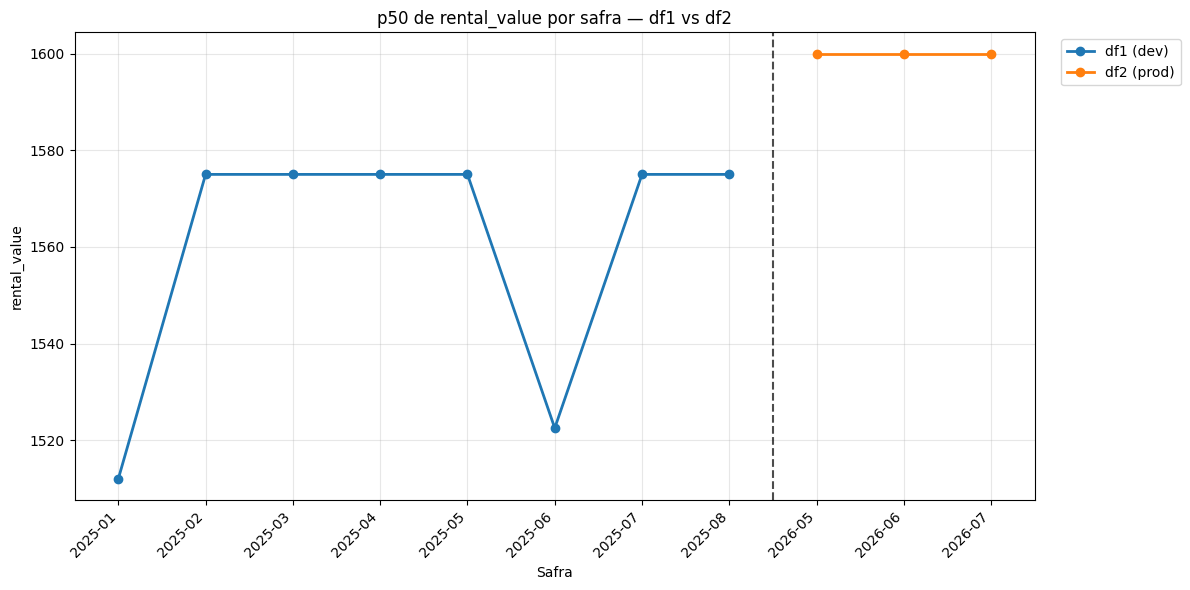

In [135]:
var = "rental_value"

s1 = (
    df1[df1["safra"] >= "2025-01"]
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
    .rename(columns={var: "p50"})
)
s1["serie"] = "df1 (dev)"

s2 = (
    df2[df2["safra"] >= "2026-05"]
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
    .rename(columns={var: "p50"})
)
s2["serie"] = "df2 (prod)"

# só safras com dado, em ordem
safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}

s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(s1["x"], s1["p50"], marker="o", linewidth=2, label="df1 (dev)")
ax.plot(s2["x"], s2["p50"], marker="o", linewidth=2, label="df2 (prod)")

# linha entre o último ponto de df1 e o primeiro de df2
sep = s1["x"].max() + 0.5
ax.axvline(sep, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel(var)
ax.set_title(f"p50 de {var} por safra — df1 vs df2")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

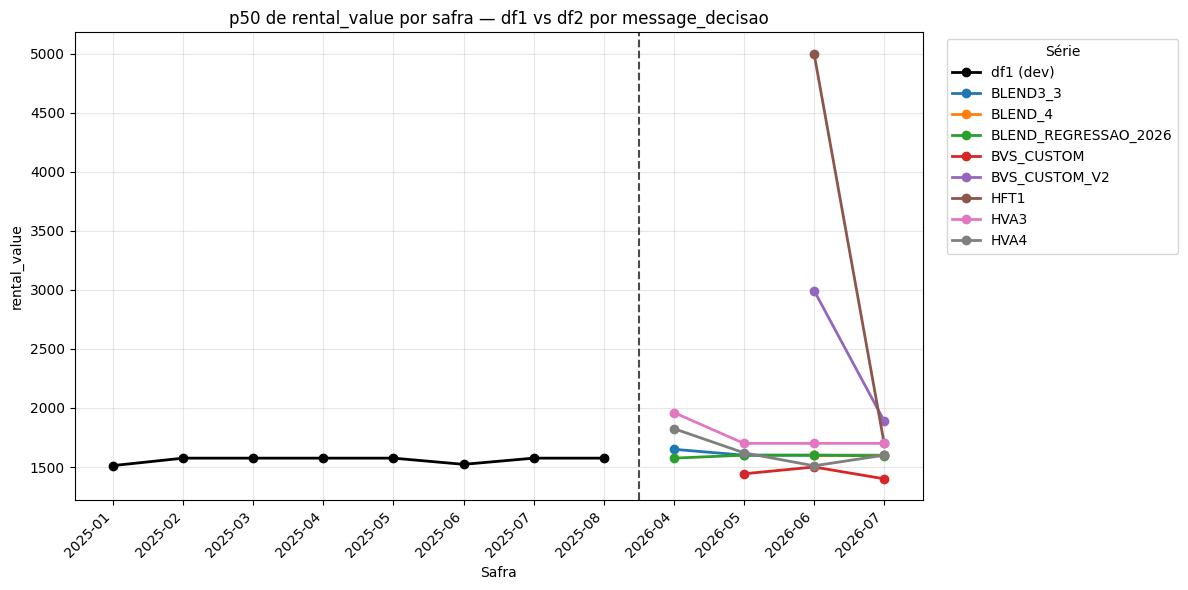

In [131]:
var = "rental_value"

s1 = (
    df1[df1["safra"] >= "2025-01"]
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
    .rename(columns={var: "p50"})
)

s2 = (
    df2.groupby(["safra", "message_decisao"], as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
    .rename(columns={var: "p50"})
)

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}

s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(s1["x"], s1["p50"], marker="o", linewidth=2, color="black", label="df1 (dev)")

for decisao, g in s2.groupby("message_decisao"):
    g = g.sort_values("x")
    ax.plot(g["x"], g["p50"], marker="o", linewidth=2, label=decisao)

sep = s1["x"].max() + 0.5
ax.axvline(sep, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel(var)
ax.set_title(f"p50 de {var} por safra — df1 vs df2 por message_decisao")
ax.grid(alpha=0.3)
ax.legend(title="Série", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Média

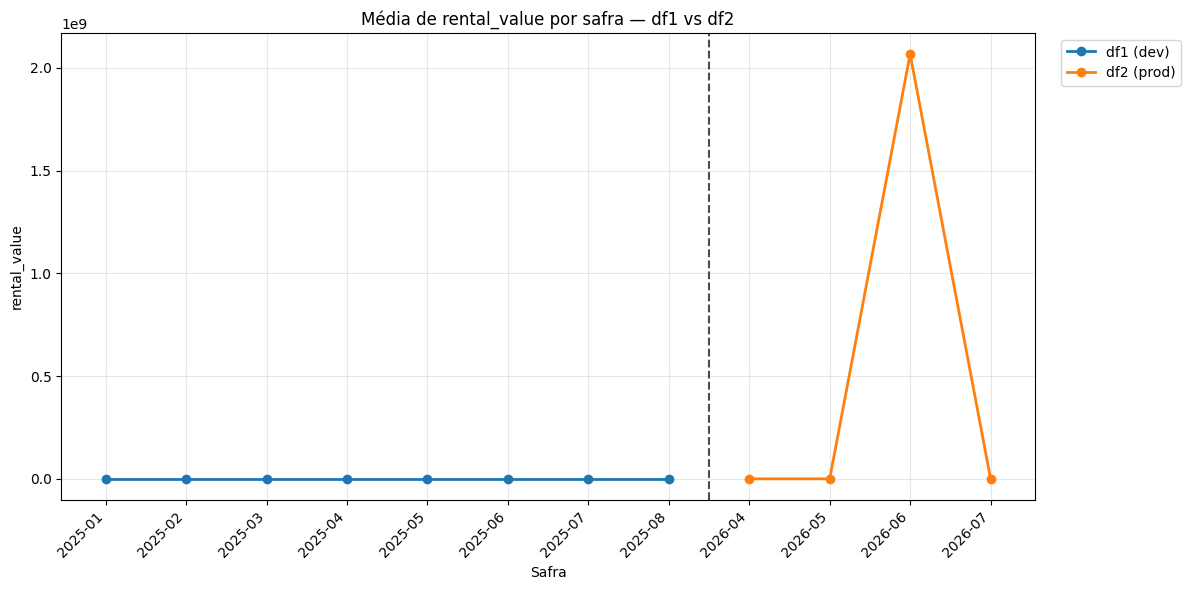

In [133]:
var = "rental_value"

s1 = (
    df1[df1["safra"] >= "2025-01"]
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
)
s1["serie"] = "df1 (dev)"

s2 = (
    df2.groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
)
s2["serie"] = "df2 (prod)"

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}

s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(s1["x"], s1["mean"], marker="o", linewidth=2, label="df1 (dev)")
ax.plot(s2["x"], s2["mean"], marker="o", linewidth=2, label="df2 (prod)")

sep = s1["x"].max() + 0.5
ax.axvline(sep, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel(var)
ax.set_title(f"Média de {var} por safra — df1 vs df2")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

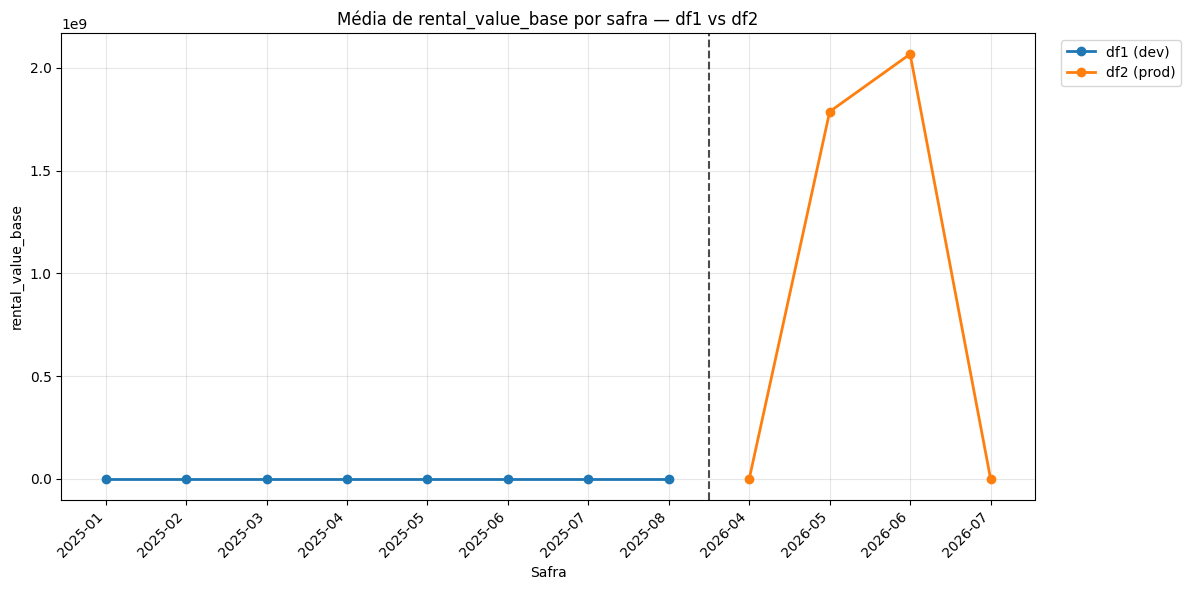

In [134]:
var = "rental_value_base"

s1 = (
    df1[df1["safra"] >= "2025-01"]
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
)
s1["serie"] = "df1 (dev)"

s2 = (
    df2.groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
)
s2["serie"] = "df2 (prod)"

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}

s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(s1["x"], s1["mean"], marker="o", linewidth=2, label="df1 (dev)")
ax.plot(s2["x"], s2["mean"], marker="o", linewidth=2, label="df2 (prod)")

sep = s1["x"].max() + 0.5
ax.axvline(sep, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel(var)
ax.set_title(f"Média de {var} por safra — df1 vs df2")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Mediana

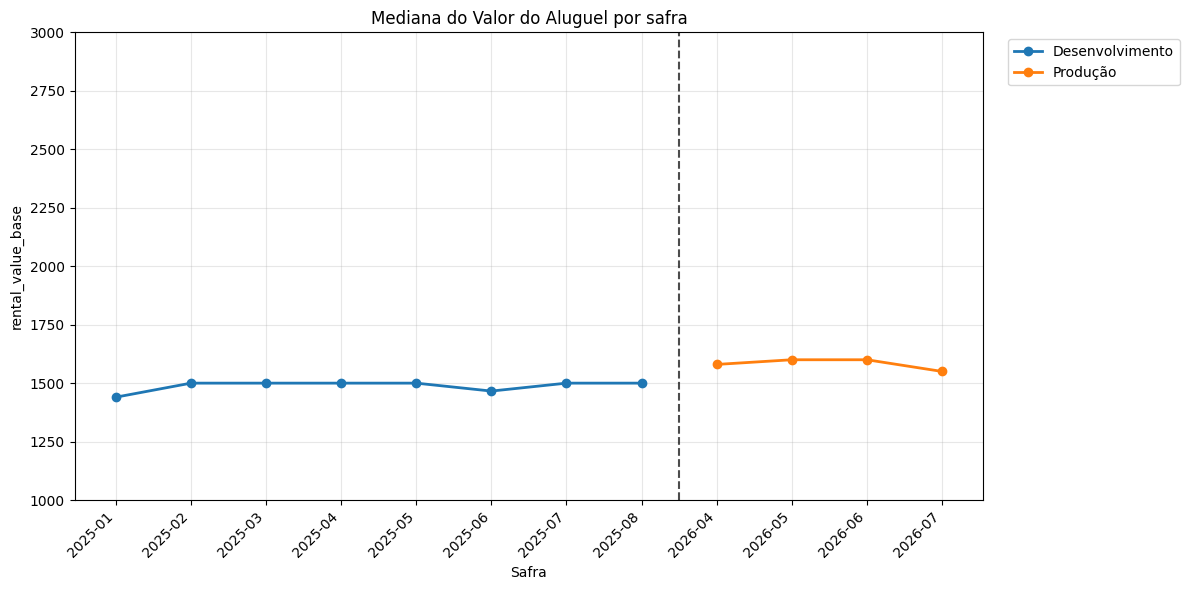

In [195]:
var = "rental_value_base"

s1 = (
    df1[df1["safra"] >= "2025-01"]
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
    .rename(columns={var: "p50"})
)
s1["serie"] = "df1 (dev)"

s2 = (
    df2.groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
    .rename(columns={var: "p50"})
)
s2["serie"] = "df2 (prod)"

# só safras com dado, em ordem
safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}

s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(s1["x"], s1["p50"], marker="o", linewidth=2, label="Desenvolvimento")
ax.plot(s2["x"], s2["p50"], marker="o", linewidth=2, label="Produção")

# linha entre o último ponto de df1 e o primeiro de df2
sep = s1["x"].max() + 0.5
ax.axvline(sep, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel(var)
ax.set_ylim(1000, 3000)
ax.set_title(f"Mediana do Valor do Aluguel por safra")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

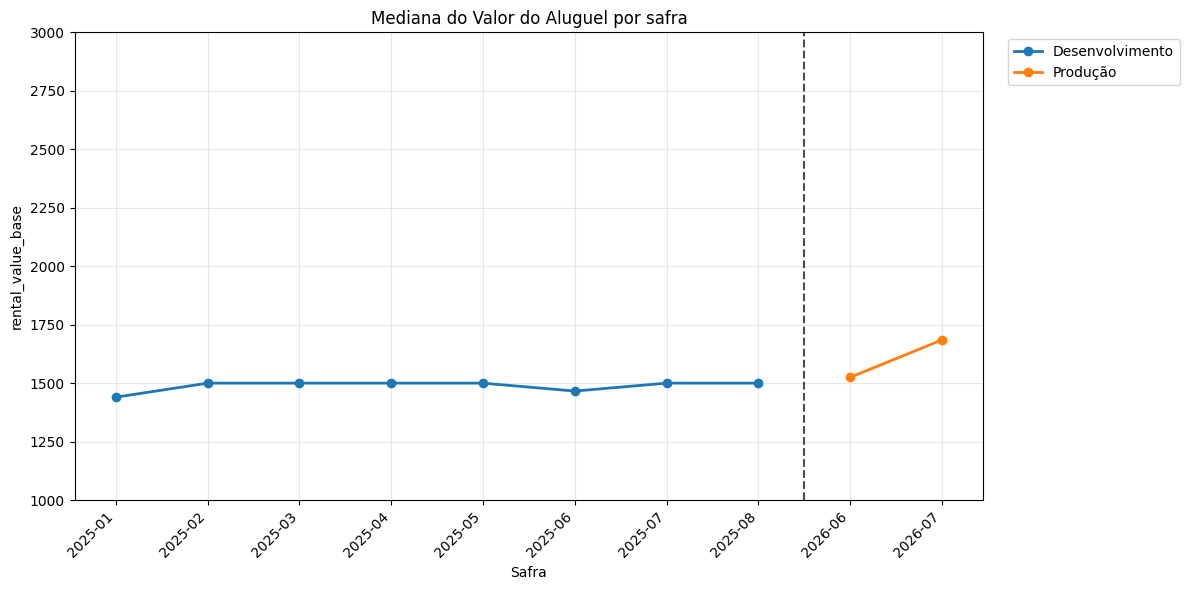

In [194]:
var = "rental_value_base"

s1 = (
    df1[df1["safra"] >= "2025-01"]
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
    .rename(columns={var: "p50"})
)
s1["serie"] = "df1 (dev)"

s2 = (
    df2[df2["message_decisao"] == "BLEND_4"].groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
    .rename(columns={var: "p50"})
)
s2["serie"] = "df2 (prod)"

# só safras com dado, em ordem
safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}

s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(s1["x"], s1["p50"], marker="o", linewidth=2, label="Desenvolvimento")
ax.plot(s2["x"], s2["p50"], marker="o", linewidth=2, label="Produção")

# linha entre o último ponto de df1 e o primeiro de df2
sep = s1["x"].max() + 0.5
ax.axvline(sep, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel(var)
ax.set_ylim(1000, 3000)
ax.set_title(f"Mediana do Valor do Aluguel por safra")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

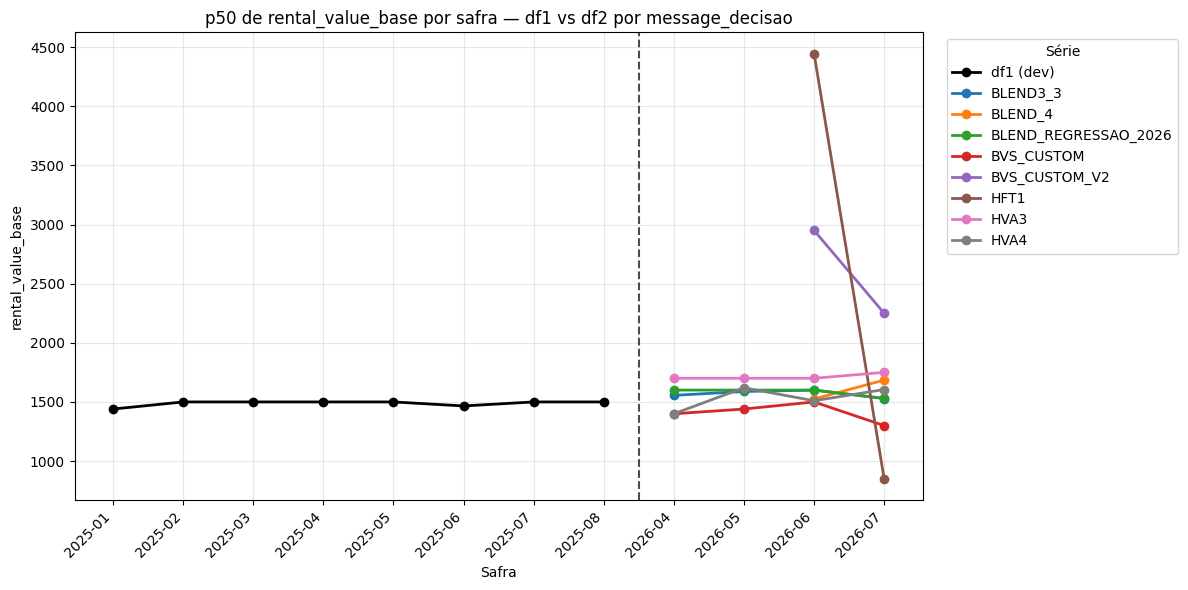

In [132]:
var = "rental_value_base"

s1 = (
    df1[df1["safra"] >= "2025-01"]
    .groupby("safra", as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
    .rename(columns={var: "p50"})
)

s2 = (
    df2.groupby(["safra", "message_decisao"], as_index=False)[var]
    .agg(p50=lambda s: s.quantile(0.50), mean="mean")
    .rename(columns={var: "p50"})
)

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}

s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(s1["x"], s1["p50"], marker="o", linewidth=2, color="black", label="df1 (dev)")

for decisao, g in s2.groupby("message_decisao"):
    g = g.sort_values("x")
    ax.plot(g["x"], g["p50"], marker="o", linewidth=2, label=decisao)

sep = s1["x"].max() + 0.5
ax.axvline(sep, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel(var)
ax.set_title(f"p50 de {var} por safra — df1 vs df2 por message_decisao")
ax.grid(alpha=0.3)
ax.legend(title="Série", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Base Funil

In [138]:
project_id = 'loft-dl-fintech'

query = '''
SELECT 
rf.contract_id,
date(rf.dt_lead) as dt_lead,
date(cf.requested_at) as requested_at,
date(rf.dt_proposta_iniciada) as iniciada_at,
date(rf.dt_proposta_enviada) as enviada_at,
date(rf.activated_at) as activated_at,
date(rf.cancelled_at) as cancelled_at,
date(rf.dt_saida) as dt_saida,
cf.tipo_contrato,
rd.product_nm,
cf.modeloBlend,
cf.bureau_nm,
cf.modelo_blend,
case when cf.modeloBlend in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') then 'BLEND4'
        when cf.bureau_nm in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') then 'BLEND4'
        when cf.modeloBlend in ('BLEND3_3', 'BVS_CUSTOM', 'HVA4') then 'BLEND3'
        when cf.bureau_nm in ('BLEND3_3', 'BVS_CUSTOM', 'HVA4') then 'BLEND3'
        else modeloBlend end as bureau_nm_ajust,
case when cf.modeloBlend in ('BVS_CUSTOM_V2', 'HFT1', 'BVS_CUSTOM', 'HVA4') then 1
        when cf.bureau_nm in ('BVS_CUSTOM_V2', 'HFT1', 'BVS_CUSTOM', 'HVA4') then 1 else 0 end as is_fallback,
cast(rf.total_rental_value_informed_nr as FLOAT64) as total_rental_value_informed_nr,
cast(rf.rental_value_nr as FLOAT64) as rental_value_nr,
cf.qtd_proponentes,
cf.score_imobiliaria,
cf.person_restriction_total_value,
ca.bvs_cust_score_nr,
ca.blend_regressao_predict_nr,
cf.rating_score_ds,
rd.pre_analysis_result,
rd.lead_elegivel,
rd.proposta_iniciada,
rd.proposta_enviada,
rd.proposta_aprovada,
rd.proposta_ativada,
rd.is_activeted
FROM loft-dl-fintech.cp_gold.requests_fact AS rf
LEFT JOIN loft-dl-fintech.cp_gold.requests_dim AS rd
ON rf.contract_id = rd.contract_id
LEFT JOIN loft-dl-fintech.cp_gold.credit_fact AS cf
ON rf.contract_id = cf.contract_id
LEFT JOIN loft-dl-fintech.cp_silver.int_credit_analyses AS ca
ON rf.contract_id = ca.contract_id
WHERE cf.tipo_contrato = 'PF'
and date(cf.requested_at) >= date('2026-01-01')
and date(cf.requested_at) < date(current_date())
'''

In [139]:
df_funil = pandas_gbq.read_gbq(query, project_id=project_id)
df_funil

Downloading: 100%|██████████|


,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,bvs_cust_score_nr,blend_regressao_predict_nr,rating_score_ds,pre_analysis_result,lead_elegivel,proposta_iniciada,proposta_enviada,proposta_aprovada,proposta_ativada,is_activeted
0,4388991,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,508.000000000,307.0,E,REPROVAR,False,False,False,False,False,False
1,4385544,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,None,335.0,E,REPROVAR,False,False,False,False,False,False
2,4387142,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,465.000000000,387.0,D,REPROVAR,False,False,False,False,False,False
3,4389315,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,None,127.0,E,REPROVAR,False,False,False,False,False,False
4,4386231,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,512.000000000,216.0,E,REPROVAR,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793590,4252298,2026-06-15,2026-06-15,2026-06-24,2026-06-24,NaT,NaT,NaT,PF,Fit,...,527.000000000,457.0,C,DERIVAR,True,True,True,False,False,False
793591,4255852,2026-06-15,2026-06-15,2026-06-22,2026-06-22,NaT,NaT,NaT,PF,Fit,...,732.000000000,614.0,B,APROVAR,True,True,True,True,False,False
793592,4253221,2026-06-15,2026-06-15,2026-06-15,NaT,NaT,2026-07-16,NaT,PF,Fit,...,743.000000000,754.0,B,APROVAR,True,True,False,False,False,False
793593,4251659,2026-06-15,2026-06-15,2026-06-19,2026-06-19,2026-06-22,NaT,NaT,PF,Smart,...,718.000000000,626.0,B,APROVAR,True,True,True,True,True,True


In [140]:
df_funil[["rental_value_nr"]].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9])

,rental_value_nr
count,7.935950e+05
mean,5.610026e+08
std,3.550809e+11
min,1.000000e+00
1%,6.000000e+02
5%,7.500000e+02
10%,8.900000e+02
25%,1.150000e+03
50%,1.530000e+03
75%,2.240000e+03


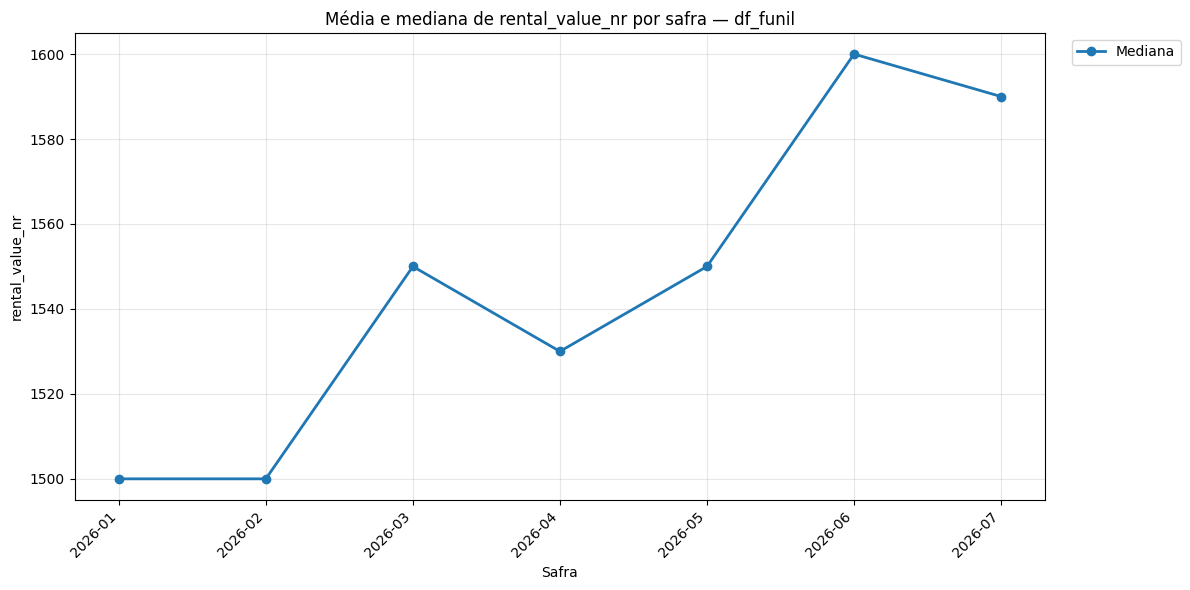

,safra,n,mean,p10,p25,median,p75,p90
0,2026-01,138650,8.086748e+05,850.0,1100.0,1500.0,2200.00,3151.08
1,2026-02,114946,3.842837e+03,875.0,1120.0,1500.0,2200.00,3291.00
2,2026-03,133277,5.791591e+04,880.0,1150.0,1550.0,2250.00,3300.00
3,2026-04,112033,2.459819e+03,880.0,1120.0,1530.0,2222.22,3300.00
4,2026-05,108722,1.840246e+09,900.0,1150.0,1550.0,2250.00,3333.33
5,2026-06,113397,2.160655e+09,900.0,1200.0,1600.0,2300.00,3420.00
6,2026-07,72570,1.718802e+04,900.0,1180.0,1590.0,2300.00,3310.00


In [151]:
df_funil["safra"] = df_funil["requested_at"].astype(str).str[:7]
df_funil["rental_value_nr"] = pd.to_numeric(df_funil["rental_value_nr"], errors="coerce")

summary = (
    df_funil.groupby("safra", as_index=False)["rental_value_nr"]
    .agg(
        n="count",
        mean="mean",
        p10=lambda s: s.quantile(0.10),
        p25=lambda s: s.quantile(0.25),
        median=lambda s: s.quantile(0.50),
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
    )
    .sort_values("safra")
)

fig, ax = plt.subplots(figsize=(12, 6))

# ax.plot(summary["safra"], summary["mean"], marker="o", linewidth=2, label="Média")
ax.plot(summary["safra"], summary["median"], marker="o", linewidth=2, label="Mediana")
# ax.plot(summary["safra"], summary["p10"], marker="o", linewidth=2, label="10%")
# ax.plot(summary["safra"], summary["p90"], marker="o", linewidth=2, label="90%")

ax.set_xlabel("Safra")
ax.set_ylabel("rental_value_nr")
ax.set_title("Média e mediana de rental_value_nr por safra — df_funil")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
# ax.set_ylim(600, 3500)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

summary

In [148]:
df_funil_rv = df_funil.merge(df_rental_value, on="contract_id", how="left")
df_funil_rv

,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,rating_score_ds,pre_analysis_result,lead_elegivel,proposta_iniciada,proposta_enviada,proposta_aprovada,proposta_ativada,is_activeted,safra,rental_value_base
0,4388991,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,E,REPROVAR,False,False,False,False,False,False,2026-07,NaN
1,4385544,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,E,REPROVAR,False,False,False,False,False,False,2026-07,NaN
2,4387142,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,D,REPROVAR,False,False,False,False,False,False,2026-07,NaN
3,4389315,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,E,REPROVAR,False,False,False,False,False,False,2026-07,NaN
4,4386231,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,E,REPROVAR,False,False,False,False,False,False,2026-07,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793590,4252298,2026-06-15,2026-06-15,2026-06-24,2026-06-24,NaT,NaT,NaT,PF,Fit,...,C,DERIVAR,True,True,True,False,False,False,2026-06,2600.00
793591,4255852,2026-06-15,2026-06-15,2026-06-22,2026-06-22,NaT,NaT,NaT,PF,Fit,...,B,APROVAR,True,True,True,True,False,False,2026-06,1300.00
793592,4253221,2026-06-15,2026-06-15,2026-06-15,NaT,NaT,2026-07-16,NaT,PF,Fit,...,B,APROVAR,True,True,False,False,False,False,2026-06,2000.00
793593,4251659,2026-06-15,2026-06-15,2026-06-19,2026-06-19,2026-06-22,NaT,NaT,PF,Smart,...,B,APROVAR,True,True,True,True,True,True,2026-06,2720.14


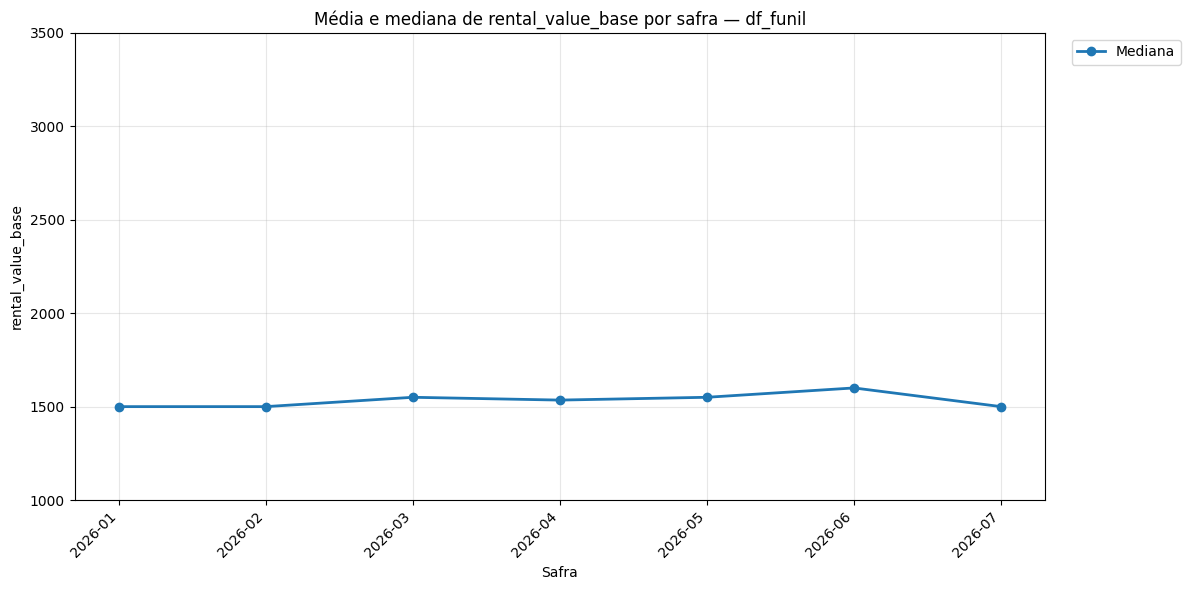

,safra,n,mean,p10,p25,median,p75,p90
0,2026-01,138650,8.086750e+05,850.00,1100.00,1500.0,2200.00,3160.00
1,2026-02,114946,3.842934e+03,875.00,1120.00,1500.0,2200.00,3293.10
2,2026-03,133277,5.791602e+04,880.00,1150.00,1550.0,2250.00,3300.00
3,2026-04,112033,2.459945e+03,880.00,1120.00,1535.0,2222.22,3300.00
4,2026-05,108722,1.840246e+09,900.00,1150.00,1550.0,2250.00,3333.33
5,2026-06,113397,2.160655e+09,900.00,1200.00,1600.0,2300.00,3420.00
6,2026-07,11128,1.025610e+04,888.97,1128.75,1500.0,2200.00,3200.00


In [156]:
df_funil_rv["safra"] = df_funil_rv["requested_at"].astype(str).str[:7]
df_funil_rv["rental_value_base"] = pd.to_numeric(df_funil_rv["rental_value_base"], errors="coerce")

summary = (
    df_funil_rv.groupby("safra", as_index=False)["rental_value_base"]
    .agg(
        n="count",
        mean="mean",
        p10=lambda s: s.quantile(0.10),
        p25=lambda s: s.quantile(0.25),
        median=lambda s: s.quantile(0.50),
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
    )
    .sort_values("safra")
)

fig, ax = plt.subplots(figsize=(12, 6))

# ax.plot(summary["safra"], summary["mean"], marker="o", linewidth=2, label="Média")
ax.plot(summary["safra"], summary["median"], marker="o", linewidth=2, label="Mediana")
# ax.plot(summary["safra"], summary["p10"], marker="o", linewidth=2, label="10%")
# ax.plot(summary["safra"], summary["p90"], marker="o", linewidth=2, label="90%")

ax.set_xlabel("Safra")
ax.set_ylabel("rental_value_base")
ax.set_title("Média e mediana de rental_value_base por safra — df_funil")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(1000, 3500)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

summary

## Consulta Realizada

In [157]:
project_id = 'loft-dl-fintech'

In [158]:
query_credpago = f"""
WITH consulta_realizada AS (
    SELECT
        CAST(REGEXP_REPLACE(documento, r'[^0-9]', '') AS INT64) AS CPF_CNPJ,
        id_externo AS contract_id,

        MIN(DATE(data)) OVER (
            PARTITION BY id_externo
        ) AS requested_at,

        MAX(DATE(data)) OVER (
            PARTITION BY id_externo
        ) AS data_ultima_consulta,
        ARRAY_LENGTH(JSON_EXTRACT_ARRAY(CR.json_retornado, '$.pessoas')) AS qtd_proponentes,
        CR.*
    FROM `loft-dl-fintech.bronze_credpago_sortinghat.consulta_realizada` CR
    WHERE DATE(data) >= DATE_SUB(CURRENT_DATE(), INTERVAL 12 WEEK)
    AND DATE(data) < CURRENT_DATE()
)

SELECT *
FROM consulta_realizada
QUALIFY ROW_NUMBER() OVER (
    PARTITION BY contract_id
    ORDER BY 
        CASE WHEN model = 'BLEND_4' THEN 1 ELSE 2 END ASC,
        data DESC
) = 1
"""

credpago_df = pd.read_gbq(query_credpago, project_id=project_id)
credpago_df

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,qtd_proponentes,score_imobiliaria,renda_considerada,model,id_externo,json_retornado,...,id_funcionalidade,_sdc_table_version,request,_sdc_received_at,_sdc_sequence,documento,rating,_sdc_batched_at,data,result
0,14592053915,4303574,2026-06-26,2026-06-26,1,B,0E-9,BLEND3_3,4303574,"{""pessoas"":[{""nome"":""CPF NAO CONFIRMADO NO CAD...",...,15,1778785248777,"{""valor_aluguel"":5200,""matchmaking_on"":false,""...",2026-06-27 08:00:48+00:00,1782547244926174820,14592053915,N,2026-06-27 08:17:33.311000+00:00,2026-06-26 15:22:59+00:00,DERIVAR
1,9456295672,4325232,2026-07-02,2026-07-02,2,NI,1712.500000000,HVA3,4325232,"{""pessoas"":[{""nome"":""CPF NAO CONFIRMADO NO CAD...",...,28,1778785248777,"{""valor_aluguel"":1300,""matchmaking_on"":false,""...",2026-07-02 18:00:58+00:00,1783015256871516265,09456295672,E,2026-07-02 18:07:55.273000+00:00,2026-07-02 14:22:26+00:00,REPROVAR
2,12044561271,4086645,2026-05-04,2026-05-04,1,NI,0E-9,BLEND3_3,4086645,"{""manual"":false,""node"":null,""pessoas"":[{""nome""...",...,15,1778785248777,None,2026-05-20 08:01:23+00:00,1779264082068010384,12044561271,N,2026-05-20 08:09:22.868000+00:00,2026-05-04 10:56:15+00:00,DERIVAR
3,71327469014,4209486,2026-06-03,2026-06-08,1,NI,0E-9,BLEND3_3,4209486,"{""pessoas"":[{""nome"":"""",""documento"":"""",""classif...",...,15,1778785248777,"{""valor_aluguel"":""5728"",""imobiliaria_id"":32268...",2026-06-08 18:00:27+00:00,1780941620661991668,71327469014,N,2026-06-08 18:09:29.450000+00:00,2026-06-08 10:08:34+00:00,DERIVAR
4,16702528760,4255313,2026-06-15,2026-06-15,1,C,0E-9,BLEND3_3,4255313,"{""pessoas"":[{""nome"":"""",""documento"":""1670252876...",...,28,1778785248777,"{""valor_aluguel"":""2000"",""imobiliaria_id"":7927,...",2026-06-16 08:00:47+00:00,1781596844859233996,16702528760,B,2026-06-16 08:04:56.790000+00:00,2026-06-15 17:29:08+00:00,APROVAR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327706,10607304995,4220289,2026-06-08,2026-06-08,1,NI,2192.000000000,BLEND3_3,4220289,"{""pessoas"":[{""nome"":""ANTUNES GABRIEL LOPES SOA...",...,37,1778785248777,"{""valor_aluguel"":""1200"",""imobiliaria_id"":21010...",2026-06-08 18:00:27+00:00,1780941619750230563,10607304995,B,2026-06-08 18:09:29.158000+00:00,2026-06-08 09:01:59+00:00,DERIVAR
327707,57670192828,4240572,2026-06-11,2026-06-11,2,NI,7055.500000000,HVA3,4240572,"{""pessoas"":[{""nome"":""TAYANA GABRIELLI BORDIN B...",...,37,1778785248777,"{""valor_aluguel"":""1800"",""imobiliaria_id"":20003...",2026-06-11 18:00:40+00:00,1781200834921994140,57670192828,D,2026-06-11 18:06:21.855000+00:00,2026-06-11 09:46:30+00:00,DERIVAR
327708,3207074669,4271209,2026-06-18,2026-06-18,1,E,7603.500000000,BLEND3_3,4271209,"{""pessoas"":[{""nome"":""LUCIANA FALCAO AVELINO"",""...",...,37,1778785248777,"{""valor_aluguel"":""1200"",""imobiliaria_id"":2141,...",2026-06-19 08:00:36+00:00,1781856032773556095,03207074669,C,2026-06-19 08:01:40.109000+00:00,2026-06-18 16:02:25+00:00,DERIVAR
327709,7015297922,4073166,2026-04-28,2026-04-28,1,NI,2740.000000000,BLEND3_3,4073166,"{""manual"":false,""node"":null,""pessoas"":[{""nome""...",...,37,1778785248777,None,2026-05-20 08:01:14+00:00,1779264072843555123,07015297922,C,2026-05-20 08:09:08.646000+00:00,2026-04-28 23:35:47+00:00,DERIVAR


In [159]:
def unwrap_payload(obj):
    """Supports old format (message wrapper) and new format (root payload)."""
    if not obj:
        return None
    if isinstance(obj, dict) and "message" in obj:
        return obj["message"]
    return obj


def extract_pessoa_fields(raw):
    if pd.isna(raw) or not raw:
        return {}
    payload = unwrap_payload(json.loads(raw) if isinstance(raw, str) else raw)
    pessoas = (payload or {}).get("pessoas") or []
    if not pessoas:
        return {}
    p = pessoas[0]  # first proponent
    scores = p.get("scores") or {}
    return {
        "pessoas_scores_BVS_CUSTOM": scores.get("BVS_CUSTOM"),
        "pessoas_scores_BVS_CUSTOM_V2": scores.get("BVS_CUSTOM_V2"),
        "pessoas_scores_HVA4": scores.get("HVA4"),
        "pessoas_scores_HFT1": scores.get("HFT1"),  # Blend4 — key is HFT1
        "pessoas_rendaConsideradaPessoa": p.get("rendaConsideradaPessoa"),
    }


pessoa_cols = credpago_df["json_retornado"].apply(extract_pessoa_fields).apply(pd.Series)
credpago_df_clean = pd.concat([credpago_df, pessoa_cols], axis=1)

In [160]:
credpago_df_clean

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,qtd_proponentes,score_imobiliaria,renda_considerada,model,id_externo,json_retornado,...,documento,rating,_sdc_batched_at,data,result,pessoas_scores_BVS_CUSTOM,pessoas_scores_BVS_CUSTOM_V2,pessoas_scores_HVA4,pessoas_scores_HFT1,pessoas_rendaConsideradaPessoa
0,14592053915,4303574,2026-06-26,2026-06-26,1,B,0E-9,BLEND3_3,4303574,"{""pessoas"":[{""nome"":""CPF NAO CONFIRMADO NO CAD...",...,14592053915,N,2026-06-27 08:17:33.311000+00:00,2026-06-26 15:22:59+00:00,DERIVAR,NaN,NaN,0.0,NaN,0.0
1,9456295672,4325232,2026-07-02,2026-07-02,2,NI,1712.500000000,HVA3,4325232,"{""pessoas"":[{""nome"":""CPF NAO CONFIRMADO NO CAD...",...,09456295672,E,2026-07-02 18:07:55.273000+00:00,2026-07-02 14:22:26+00:00,REPROVAR,NaN,NaN,NaN,NaN,0.0
2,12044561271,4086645,2026-05-04,2026-05-04,1,NI,0E-9,BLEND3_3,4086645,"{""manual"":false,""node"":null,""pessoas"":[{""nome""...",...,12044561271,N,2026-05-20 08:09:22.868000+00:00,2026-05-04 10:56:15+00:00,DERIVAR,NaN,NaN,0.0,NaN,0.0
3,71327469014,4209486,2026-06-03,2026-06-08,1,NI,0E-9,BLEND3_3,4209486,"{""pessoas"":[{""nome"":"""",""documento"":"""",""classif...",...,71327469014,N,2026-06-08 18:09:29.450000+00:00,2026-06-08 10:08:34+00:00,DERIVAR,NaN,NaN,0.0,NaN,0.0
4,16702528760,4255313,2026-06-15,2026-06-15,1,C,0E-9,BLEND3_3,4255313,"{""pessoas"":[{""nome"":"""",""documento"":""1670252876...",...,16702528760,B,2026-06-16 08:04:56.790000+00:00,2026-06-15 17:29:08+00:00,APROVAR,719.0,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327706,10607304995,4220289,2026-06-08,2026-06-08,1,NI,2192.000000000,BLEND3_3,4220289,"{""pessoas"":[{""nome"":""ANTUNES GABRIEL LOPES SOA...",...,10607304995,B,2026-06-08 18:09:29.158000+00:00,2026-06-08 09:01:59+00:00,DERIVAR,598.0,NaN,469.0,NaN,2192.0
327707,57670192828,4240572,2026-06-11,2026-06-11,2,NI,7055.500000000,HVA3,4240572,"{""pessoas"":[{""nome"":""TAYANA GABRIELLI BORDIN B...",...,57670192828,D,2026-06-11 18:06:21.855000+00:00,2026-06-11 09:46:30+00:00,DERIVAR,NaN,NaN,NaN,NaN,2397.5
327708,3207074669,4271209,2026-06-18,2026-06-18,1,E,7603.500000000,BLEND3_3,4271209,"{""pessoas"":[{""nome"":""LUCIANA FALCAO AVELINO"",""...",...,03207074669,C,2026-06-19 08:01:40.109000+00:00,2026-06-18 16:02:25+00:00,DERIVAR,549.0,NaN,686.0,NaN,7603.5
327709,7015297922,4073166,2026-04-28,2026-04-28,1,NI,2740.000000000,BLEND3_3,4073166,"{""manual"":false,""node"":null,""pessoas"":[{""nome""...",...,07015297922,C,2026-05-20 08:09:08.646000+00:00,2026-04-28 23:35:47+00:00,DERIVAR,689.0,NaN,361.0,NaN,2740.0


## Renda Média

Avaliar média e mediana ao longo dos meses

Ver Renda média ao longo das safras
Precisa saber onde tem renda e onde tem o score bvs > 334

In [161]:
funil_ids = set(df_funil_rv["contract_id"].dropna().astype(str))
credpago_ids = set(credpago_df_clean["contract_id"].dropna().astype(str))

missing = funil_ids - credpago_ids
matched = funil_ids & credpago_ids

print(f"funil unique:     {len(funil_ids):,}")
print(f"credpago unique:  {len(credpago_ids):,}")
print(f"matched:          {len(matched):,} ({100 * len(matched) / len(funil_ids):.1f}%)")
print(f"missing in credpago: {len(missing):,} ({100 * len(missing) / len(funil_ids):.1f}%)")

# where the gaps concentrate
df_funil_rv.assign(
    _id=df_funil_rv["contract_id"].astype(str),
    match=lambda d: d["_id"].isin(credpago_ids),
).groupby(df_funil_rv["requested_at"].astype(str).str[:7])["match"].agg(
    n="count", matched="sum", pct=lambda s: 100 * s.mean()
)

funil unique:     793,595
credpago unique:  327,711
matched:          311,859 (39.3%)
missing in credpago: 481,736 (60.7%)


,n,matched,pct
requested_at,,,
2026-01,138650,1,0.000721
2026-02,114946,18,0.015660
2026-03,133277,47,0.035265
2026-04,112033,17247,15.394571
2026-05,108722,108722,100.000000
2026-06,113397,113273,99.890650
2026-07,72570,72551,99.973818


In [165]:
df_funil_rv["contract_id"] = pd.to_numeric(df_funil_rv["contract_id"], errors="coerce").astype("Int64")
credpago_df_clean["contract_id"] = pd.to_numeric(credpago_df_clean["contract_id"], errors="coerce").astype("Int64")

df_funil_rv["safra"] = pd.to_datetime(df_funil_rv["requested_at"]).dt.strftime("%Y-%m")
credpago_df_clean["safra"] = pd.to_datetime(credpago_df_clean["requested_at"]).dt.strftime("%Y-%m")

# 2) only safras present in credpago (overlap window)
safras_credpago = sorted(credpago_df_clean["safra"].dropna().unique())
print("Safras CredPago:", safras_credpago)

df_funil_rv_safras = df_funil_rv[df_funil_rv["safra"].isin(safras_credpago)].copy()

# 3) left merge on contract_id
df_merged = df_funil_rv_safras.merge(
    credpago_df_clean,
    on="contract_id",
    how="left",
    suffixes=("", "_credpago"),
    indicator=True,
)

# 4) coverage check
print(df_merged["_merge"].value_counts())
print(
    "Match rate:",
    (df_merged["_merge"] == "both").mean(),
)

Safras CredPago: ['2026-04', '2026-05', '2026-06', '2026-07']
_merge
both          311793
left_only      94929
right_only         0
Name: count, dtype: int64
Match rate: 0.7665997905203062


In [173]:
df_merged_renda = df_merged[(df_merged["pessoas_scores_HFT1"]>334)&(df_merged["safra"].isin(["2026-05", "2026-06", "2026-07"]))]
df_merged_renda

,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,_sdc_batched_at,data,result,pessoas_scores_BVS_CUSTOM,pessoas_scores_BVS_CUSTOM_V2,pessoas_scores_HVA4,pessoas_scores_HFT1,pessoas_rendaConsideradaPessoa,safra_credpago,_merge
0,4388991,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,2026-07-18 08:02:32.940000+00:00,2026-07-17 16:31:21+00:00,APROVAR,NaN,589.0,NaN,471.0,12741.0,2026-07,both
1,4385544,2026-07-17,2026-07-17,NaT,NaT,NaT,2026-07-17,NaT,PF,None,...,2026-07-17 18:08:58.716000+00:00,2026-07-17 10:02:44+00:00,REPROVAR,NaN,442.0,NaN,349.0,2466.0,2026-07,both
15,4389524,2026-07-17,2026-07-17,NaT,NaT,NaT,NaT,NaT,PF,None,...,2026-07-18 08:02:33.370000+00:00,2026-07-17 17:33:30+00:00,APROVAR,NaN,514.0,NaN,384.0,4041.5,2026-07,both
26,4387690,2026-07-17,2026-07-17,NaT,NaT,NaT,NaT,NaT,PF,None,...,2026-07-17 18:08:59.749000+00:00,2026-07-17 14:16:49+00:00,APROVAR,NaN,526.0,NaN,641.0,12604.0,2026-07,both
30,4388391,2026-07-17,2026-07-17,NaT,NaT,NaT,NaT,NaT,PF,None,...,2026-07-18 08:02:32.418000+00:00,2026-07-17 15:25:48+00:00,APROVAR,NaN,648.0,NaN,456.0,108230.0,2026-07,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403628,4334356,2026-07-06,2026-07-06,NaT,NaT,NaT,2026-07-06,NaT,PF,None,...,2026-07-06 18:02:16.875000+00:00,2026-07-06 09:29:05+00:00,REPROVAR,NaN,600.0,NaN,471.0,2466.0,2026-07,both
403646,4339820,2026-07-06,2026-07-06,NaT,NaT,NaT,2026-07-06,NaT,PF,None,...,2026-07-07 08:02:57.736000+00:00,2026-07-06 19:03:04+00:00,REPROVAR,NaN,395.0,NaN,363.0,3836.0,2026-07,both
403664,4337809,2026-07-06,2026-07-06,NaT,NaT,NaT,NaT,NaT,PF,None,...,2026-07-07 08:02:55.770000+00:00,2026-07-06 15:20:54+00:00,APROVAR,NaN,514.0,NaN,574.0,12535.5,2026-07,both
403678,4338763,2026-07-06,2026-07-06,NaT,NaT,NaT,NaT,NaT,PF,None,...,2026-07-13 18:01:05.606000+00:00,2026-07-13 10:14:56+00:00,APROVAR,NaN,462.0,NaN,451.0,2671.5,2026-07,both


In [175]:
df1.income

0           4384.0
1           1575.5
2          42196.0
3           6507.5
4           2123.5
            ...   
1070231     8836.5
1070232     1233.0
1070233     1507.0
1070234     5206.0
1070235     3014.0
Name: income, Length: 1070236, dtype: float64

In [176]:
df_merged_renda.pessoas_rendaConsideradaPessoa

0          12741.0
1           2466.0
15          4041.5
26         12604.0
30        108230.0
            ...   
403628      2466.0
403646      3836.0
403664     12535.5
403678      2671.5
403680      1712.5
Name: pessoas_rendaConsideradaPessoa, Length: 4505, dtype: float64

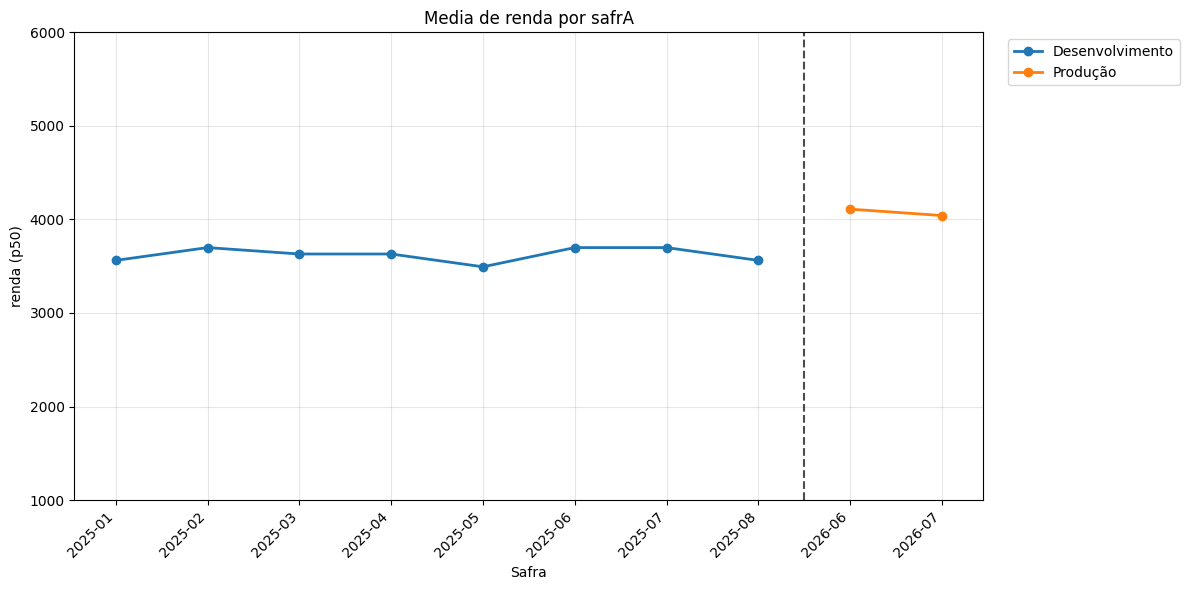

In [190]:
var_dev = "income"
var_prod = "pessoas_rendaConsideradaPessoa"

s1 = (
    df1[df1["safra"] >= "2025-01"]
    .assign(**{var_dev: lambda d: pd.to_numeric(d[var_dev], errors="coerce")})
    .groupby("safra", as_index=False)[var_dev]
    .agg(p50=lambda s: s.quantile(0.50))
)
s1["serie"] = "df1 (dev) — income"

s2 = (
    df_merged_renda
    .assign(**{var_prod: lambda d: pd.to_numeric(d[var_prod], errors="coerce")})
    .groupby("safra", as_index=False)[var_prod]
    .agg(p50=lambda s: s.quantile(0.50))
)
s2["serie"] = "prod — pessoas_rendaConsideradaPessoa"

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}

s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(s1["x"], s1["p50"], marker="o", linewidth=2, label="Desenvolvimento")
ax.plot(s2["x"], s2["p50"], marker="o", linewidth=2, label="Produção")

sep = s1["x"].max() + 0.5
ax.axvline(sep, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel("renda (p50)")
ax.set_ylim(1000, 6000)
ax.set_title("Media de renda por safrA")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

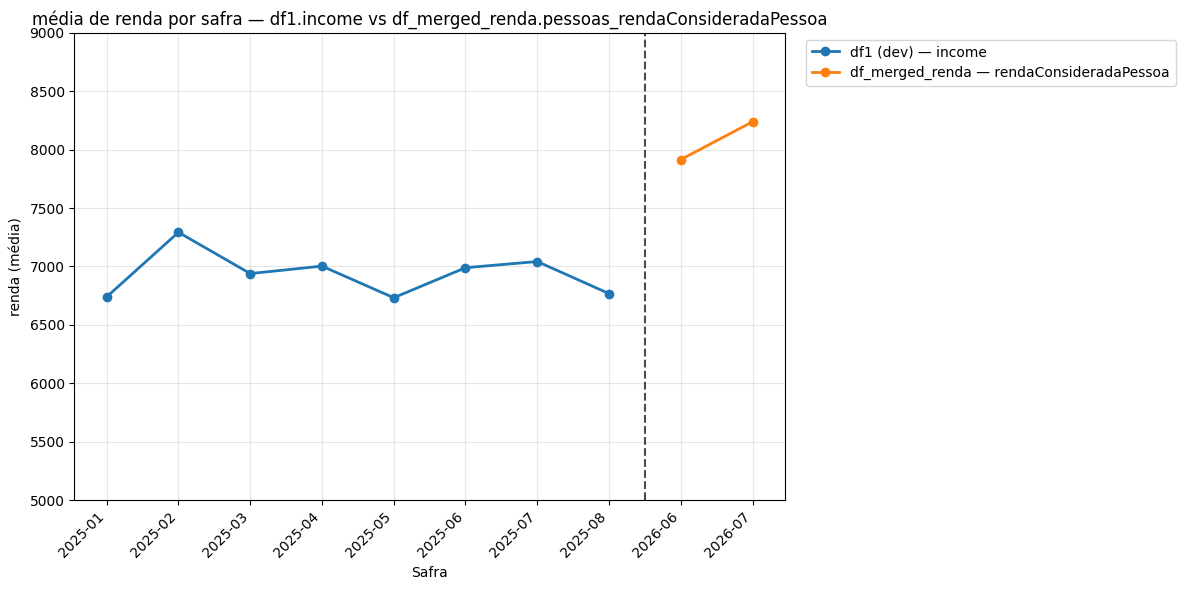

In [182]:
var_dev = "income"
var_prod = "pessoas_rendaConsideradaPessoa"

s1 = (
    df1[df1["safra"] >= "2025-01"]
    .assign(**{var_dev: lambda d: pd.to_numeric(d[var_dev], errors="coerce")})
    .groupby("safra", as_index=False)[var_dev]
    .agg(mean="mean")
)
s1["serie"] = "df1 (dev) — income"

s2 = (
    df_merged_renda
    .assign(**{var_prod: lambda d: pd.to_numeric(d[var_prod], errors="coerce")})
    .groupby("safra", as_index=False)[var_prod]
    .agg(mean="mean")
)
s2["serie"] = "prod — pessoas_rendaConsideradaPessoa"

safras = sorted(set(s1["safra"]).union(s2["safra"]))
x_map = {s: i for i, s in enumerate(safras)}

s1["x"] = s1["safra"].map(x_map)
s2["x"] = s2["safra"].map(x_map)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(s1["x"], s1["mean"], marker="o", linewidth=2, label="df1 (dev) — income")
ax.plot(s2["x"], s2["mean"], marker="o", linewidth=2, label="df_merged_renda — rendaConsideradaPessoa")

sep = s1["x"].max() + 0.5
ax.axvline(sep, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(safras)))
ax.set_xticklabels(safras, rotation=45, ha="right")
ax.set_xlabel("Safra")
ax.set_ylabel("renda (média)")
ax.set_ylim(5000, 9000)
ax.set_title("média de renda por safra — df1.income vs df_merged_renda.pessoas_rendaConsideradaPessoa")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## PC 4m

In [183]:
project_id = 'loft-dl-fintech'

query_sql = '''
WITH 
first_defaults AS (
  SELECT
    contract_id,
    DATE(MIN(pendency_at)) AS com_comp
  FROM `loft-dl-fintech.cp_gold.watchlist_fact`
  WHERE pendency_type IN ('Inadimplência', 'Inadimplência')
  GROUP BY contract_id
),
leads_e_defaults AS (
  SELECT
    r.contract_id,
    DATE(cf.requested_at) AS requested_at,
    CASE WHEN rd.pre_analysis_result IN ('DERIVAR', 'APROVAR') THEN 1 ELSE 0 END AS lead_elegivel_pre_analysis,
    DATE(r.activated_at) AS activated_at,
    i.id_cidade_ibge,
    fd.com_comp,
    DATE_DIFF(
      DATE_TRUNC(CURRENT_DATE(), MONTH),
      DATE_TRUNC(COALESCE(DATE(r.activated_at), DATE(cf.requested_at)), MONTH),
      MONTH
    ) AS time2requested,
    CASE
      WHEN fd.com_comp IS NULL OR r.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE_TRUNC(DATE(fd.com_comp), MONTH),
        DATE_TRUNC(DATE(r.activated_at), MONTH),
        MONTH
      )
    END AS time2def
  FROM `loft-dl-fintech.cp_gold.requests_fact` r
  LEFT JOIN `loft-dl-fintech.cp_gold.requests_dim` AS rd
    ON r.contract_id = rd.contract_id
  LEFT JOIN `loft-dl-fintech.cp_gold.credit_fact` AS cf
    ON r.contract_id = cf.contract_id
  LEFT JOIN `loft-dl-fintech.bronze_credpago.imovel` i
    ON r.contract_id = i.id
  LEFT JOIN first_defaults fd
    ON fd.contract_id = r.contract_id
  WHERE 1=1
    AND DATE(cf.requested_at) >= DATE_SUB(DATE('2026-05-01'), INTERVAL 25 MONTH)
    AND DATE(cf.requested_at) <  DATE('2026-05-01')
    AND cf.tipo_contrato = 'PF'
),
leads_e_defaults_mob AS (
  SELECT
    *,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN com_comp IS NOT NULL AND time2requested >= 4 AND time2def <= 4 THEN 1
      WHEN time2requested >= 4 THEN 0
      ELSE NULL
    END AS comunicado_4,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN com_comp IS NOT NULL AND time2requested >= 6 AND time2def <= 6 THEN 1
      WHEN time2requested >= 6 THEN 0
      ELSE NULL
    END AS comunicado_6,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN com_comp IS NOT NULL AND time2requested >= 12 AND time2def <= 12 THEN 1
      WHEN time2requested >= 12 THEN 0
      ELSE NULL
    END AS comunicado_12
  FROM leads_e_defaults
)
SELECT *
FROM leads_e_defaults_mob
WHERE comunicado_4 IS NOT NULL
   OR comunicado_6 IS NOT NULL
   OR comunicado_12 IS NOT NULL
'''

df_inad = pd.read_gbq(query_sql, project_id=project_id)
df_inad

,contract_id,requested_at,lead_elegivel_pre_analysis,activated_at,id_cidade_ibge,com_comp,time2requested,time2def,comunicado_4,comunicado_6,comunicado_12
0,1993142,2024-10-18,1,2020-10-18,3540754,2024-12-10,69,50,0,0,0
1,3782398,2026-02-18,1,2026-03-02,3518800,None,4,<NA>,0,<NA>,<NA>
2,3795406,2026-02-20,1,2026-03-02,4208203,2026-05-10,4,2,1,<NA>,<NA>
3,3789891,2026-02-20,1,2026-03-19,4209003,2026-05-07,4,2,1,<NA>,<NA>
4,3808520,2026-02-24,1,2026-03-03,3554102,None,4,<NA>,0,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...
389874,1679499,2024-04-12,1,2024-04-12,4320008,None,27,<NA>,0,0,0
389875,1708414,2024-04-30,1,2024-04-30,4305108,None,27,<NA>,0,0,0
389876,1708986,2024-04-30,1,2024-04-30,3549706,2024-07-30,27,3,1,1,1
389877,1708234,2024-04-30,1,2024-04-30,3205002,None,27,<NA>,0,0,0


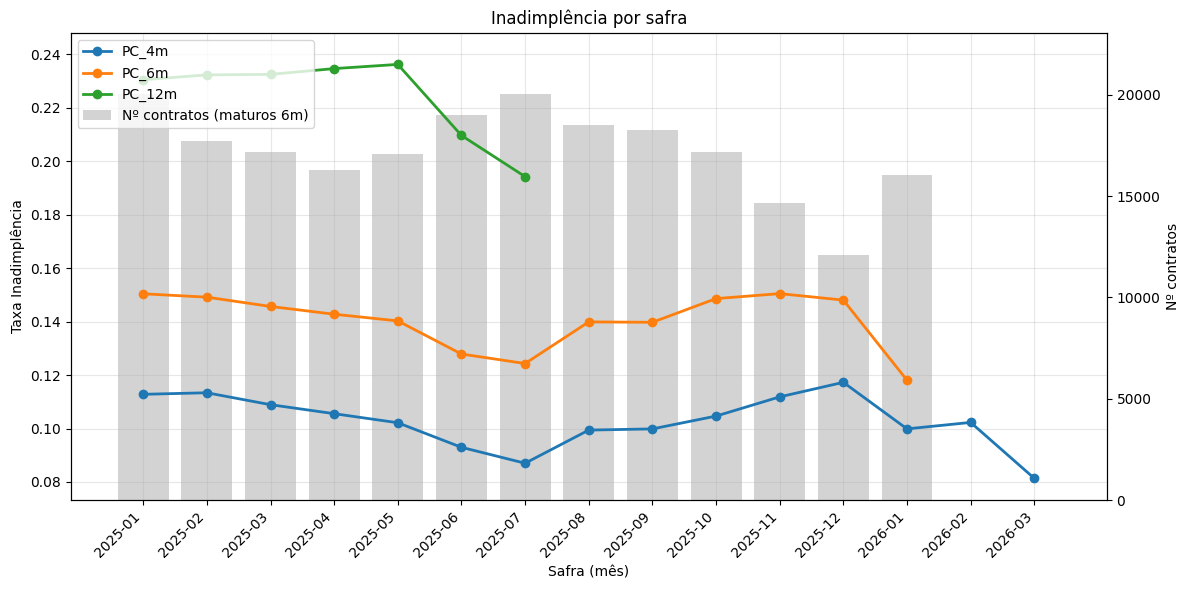

,safra,n_4,pc_4m,n_6,pc_6m,n_12,pc_12m,n
9,2025-01,20053,0.112801,20053,0.150401,20053,0.230489,20053
10,2025-02,17728,0.11338,17728,0.149143,17728,0.232288,17728
11,2025-03,17197,0.108914,17197,0.145665,17197,0.232482,17197
12,2025-04,16314,0.105554,16314,0.142761,16314,0.234645,16314
13,2025-05,17061,0.102163,17061,0.140261,17061,0.236211,17061
14,2025-06,19027,0.092973,19027,0.127871,18976,0.209633,19027
15,2025-07,20030,0.087019,20030,0.124314,17948,0.194228,20030
16,2025-08,18508,0.099416,18508,0.139885,0,<NA>,18508
17,2025-09,18255,0.099863,18255,0.139743,0,<NA>,18255
18,2025-10,17180,0.104657,17180,0.148603,0,<NA>,17180


In [185]:
df_plot = df_inad.copy()
df_plot["safra"] = pd.to_datetime(df_plot["requested_at"]).dt.to_period("M").astype(str)

summary = (
    df_plot.groupby("safra", as_index=False)
    .agg(
        n_4=("comunicado_4", "count"),
        pc_4m=("comunicado_4", "mean"),
        n_6=("comunicado_6", "count"),
        pc_6m=("comunicado_6", "mean"),
        n_12=("comunicado_12", "count"),
        pc_12m=("comunicado_12", "mean"),
    )
    .sort_values("safra")
)

summary = summary[summary["safra"] >= "2025-01"].copy()
summary["n"] = summary["n_6"]

fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()

# bars in the background
ax2.bar(
    summary["safra"],
    summary["n"],
    color="lightgray",
    width=0.8,
    label="Nº contratos (maturos 6m)",
    zorder=1,
)

# lines in front
ax.plot(summary["safra"], summary["pc_4m"], marker="o", linewidth=2, label="PC_4m", zorder=3)
ax.plot(summary["safra"], summary["pc_6m"], marker="o", linewidth=2, label="PC_6m", zorder=3)
ax.plot(summary["safra"], summary["pc_12m"], marker="o", linewidth=2, label="PC_12m", zorder=3)

# put left axis (lines) above right axis (bars)
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

ax.set_xlabel("Safra (mês)")
ax.set_ylabel("Taxa Inadimplência")
ax2.set_ylabel("Nº contratos")
ax.set_title("Inadimplência por safra")
ax.grid(alpha=0.3)

ax.set_ylim(
    max(0, summary[["pc_4m", "pc_6m", "pc_12m"]].min().min() * 0.9),
    summary[["pc_4m", "pc_6m", "pc_12m"]].max().max() * 1.05,
)
ax2.set_ylim(0, summary["n"].max() * 1.15)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

summary